In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010030rest 20160324 1054..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020025rest 20150713 1519..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010013rest 20150703 1333..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020016rest 20150701 1040..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020015_rest 20150630 1527.csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010022restnew 20150724 14.csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020027rest 20150713 1049..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010008_rest 20150619 1653.csv
/kaggle/input/preprocessed-raw-m

# **SETUP SAVE AND SPLITS**

In [2]:
# ================================================================================================
# CELL 1 — MODMA EEG Dataset: Setup + Load + Preprocess + Subject-Wise Split + Save
# ================================================================================================
#
# CRITICAL METHODOLOGICAL CORRECTIONS IMPLEMENTED:
# ------------------------------------------------
# 1. SUBJECT-WISE SPLITTING: All epochs/samples from each subject remain exclusively in either
# train OR test set — never split across both. This prevents data leakage where models learn
# subject-specific EEG "fingerprints" rather than depression biomarkers.
# Reference: Brookshire et al. (2024) "Data leakage in deep learning studies of translational EEG"
#
# 2. CORRECT NORMALIZATION ORDER: StandardScaler is fit ONLY on training data, then applied
# (transform only) to test data. Computing statistics on full dataset before splitting
# leaks test information into training preprocessing.
# Reference: scikit-learn documentation "Common pitfalls and recommended practices"
#
# 3. TEMPORAL STRUCTURE PRESERVATION: For TCN/CNN architectures, the sequential ordering of
# timepoints within epochs is preserved. No shuffling of samples within recording segments.
#
# 4. SUBJECT ID EXTRACTION: MODMA filenames encode subject identity and diagnosis:
# - "0201_XXX" prefix → MDD patient (Major Depressive Disorder)
# - "0203_XXX" prefix → HC subject (Healthy Control)
# This is used for both label verification and subject-wise partitioning.
#
# DATASET: MODMA (Multi-modal Open Dataset for Mental-disorder Analysis)
# - 128-channel EGI HydroCel Geodesic Sensor Net
# - 250 Hz sampling rate
# - 5-minute eyes-closed resting-state recordings
# - 24 MDD patients, 29 healthy controls (N=53)
# - Reference: Cai et al. (2022) Scientific Data, DOI: 10.1038/s41597-022-01211-x
#
# ================================================================================================
import os
import re
import json
import warnings
from collections import defaultdict
from typing import Tuple, Dict, List, Optional
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import tensorflow as tf
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
# ================================================================================================
# CONFIGURATION — EDIT THESE PATHS FOR YOUR SYSTEM
# ================================================================================================
# Windows example: DATA_DIR = r"C:\Users\YourName\Documents\EEG_Data\csv_files"
# Windows example: OUTPUT_DIR = r"C:\Users\YourName\Documents\EEG_Results"
DATA_DIR = "/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2"
OUTPUT_DIR = "/kaggle/working/mat-main-results"
# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ================================================================================================
# HYPERPARAMETERS
# ================================================================================================
SAMPLE_FRAC = 1.0 # Set to 0.1 for quick debugging; 1.0 for full dataset
TEST_SIZE = 0.2 # Fraction of SUBJECTS (not samples) held out for testing
SEED = 42 # Random seed for reproducibility
VALIDATE_NO_LEAKAGE = True # Programmatically verify zero subject overlap between train/test
# PCA Configuration — DISABLED by default to preserve spatial EEG channel structure
# TCN and CNN architectures exploit spatial relationships between electrodes;
# PCA destroys this topological information by creating linear combinations of channels.
USE_IPCA = False # Set True only for traditional ML (SVM, RF) with feature vectors
IPCA_COMPONENTS = 128 # Ignored when USE_IPCA=False
IPCA_BATCH = 5000
# Temporal Windowing Parameters
WINDOW_SIZE = 250 # 1 second at 250 Hz sampling rate
STRIDE = 125 # 50% overlap for smoother transitions
# Set random seeds for reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)
# ================================================================================================
# GPU CONFIGURATION (Optional — works on Windows with CUDA installed)
# ================================================================================================
gpus = tf.config.experimental.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
        print(f"✓ GPU memory growth enabled: {g}")
    except Exception as e:
        print(f"✗ GPU config failed: {e}")
if not gpus:
    print("ℹ No GPU detected — running on CPU (this is fine for preprocessing)")
# ================================================================================================
# HELPER FUNCTIONS
# ================================================================================================
def extract_subject_id_and_label(filename: str) -> Tuple[Optional[str], Optional[int]]:
    """
    Extract subject ID and diagnostic label from MODMA filename convention.
  
    MODMA Naming Convention:
    ------------------------
    - "0201_XXX.csv" → MDD patient (label = 1)
    - "0203_XXX.csv" → Healthy Control (label = 0)
  
    The subject ID is the full prefix before any additional identifiers,
    ensuring all epochs from one recording session stay together.
  
    Parameters:
        filename: CSV filename (e.g., "0201_001_epoch1.csv")
  
    Returns:
        (subject_id, label) tuple, or (None, None) if pattern doesn't match
    """
    basename = os.path.splitext(filename)[0]
  
    # Pattern 1: Standard MODMA format "0201_XXX" or "0203_XXX"
    # The first 4 digits encode the diagnostic group
    match = re.match(r'^(020[13])[-_]?(\d+)', basename)
    if match:
        group_code = match.group(1)
        subject_num = match.group(2)
        subject_id = f"{group_code}_{subject_num}"
        label = 1 if group_code == "0201" else 0 # MDD=1, HC=0
        return subject_id, label
  
    # Pattern 2: Alternative format with explicit condition markers
    # e.g., "MDD_subj01" or "HC_subj01"
    match = re.match(r'^(MDD|HC)[-_]?(.+)', basename, re.IGNORECASE)
    if match:
        condition = match.group(1).upper()
        subject_num = match.group(2)
        subject_id = f"{condition}_{subject_num}"
        label = 1 if condition == "MDD" else 0
        return subject_id, label
  
    # Pattern 3: Fallback — use entire filename as subject ID, label unknown
    # This triggers a warning and requires manual label assignment
    return basename, None
def detect_eeg_columns(columns: List[str]) -> List[str]:
    """
    Detect EEG electrode columns from DataFrame column names.
  
    Supports common naming conventions:
    - E1, E2, ..., E128 (EGI format)
    - EEG1, EEG2, ..., EEG128
    - EEG_1, EEG_2, etc.
  
    Returns columns sorted by electrode number to preserve spatial ordering.
    """
    regex = re.compile(r'^(?:EEG[_\-\s]?|E[_\-\s]?)(0*)(\d{1,3})$', flags=re.IGNORECASE)
    found = {}
  
    for col in columns:
        match = regex.match(col.strip())
        if match:
            electrode_num = int(match.group(2))
            if 1 <= electrode_num <= 128:
                found[electrode_num] = col
  
    if found:
        # Return columns sorted by electrode number (preserves spatial topology)
        return [found[i] for i in sorted(found.keys())]
  
    # Fallback: any column starting with E or EEG followed by digits
    fallback = [c for c in columns if re.match(r'^(E|EEG)\d+', c, flags=re.IGNORECASE)]
    if fallback:
        return fallback
  
    return []
def verify_no_subject_leakage(train_subjects: set, test_subjects: set) -> bool:
    """
    CRITICAL VALIDATION: Verify zero overlap between training and test subjects.
  
    This check prevents the most common methodological error in EEG classification
    literature, which inflates accuracy by 20-50 percentage points.
  
    Raises AssertionError if any subject appears in both sets.
    """
    overlap = train_subjects & test_subjects
    if overlap:
        raise AssertionError(
            f"DATA LEAKAGE DETECTED! {len(overlap)} subject(s) appear in both train and test sets: "
            f"{overlap}. This invalidates all classification results."
        )
    return True
def subject_wise_train_test_split(
    X: np.ndarray,
    y: np.ndarray,
    subject_ids: np.ndarray,
    test_size: float = 0.2,
    random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Split data ensuring ALL samples from each subject remain in either train OR test set.
  
    This is the methodologically correct approach for EEG-based diagnostic classification.
    Standard train_test_split operates on samples, which causes severe data leakage when
    multiple samples come from the same subject (as in epoched EEG data).
  
    Parameters:
        X: Feature matrix, shape (n_samples, n_features) or (n_samples, n_channels, n_timepoints)
        y: Labels, shape (n_samples,)
        subject_ids: Subject identifier for each sample, shape (n_samples,)
        test_size: Fraction of SUBJECTS to hold out (not fraction of samples)
        random_state: Random seed for reproducibility
  
    Returns:
        X_train, X_test, y_train, y_test, subjects_train, subjects_test
    """
    unique_subjects = np.unique(subject_ids)
    subject_labels = []
  
    # Get the label for each subject (should be consistent across all their samples)
    for subj in unique_subjects:
        subj_mask = subject_ids == subj
        subj_label = y[subj_mask][0] # Take first label (all should be identical)
      
        # Verify label consistency within subject
        if not np.all(y[subj_mask] == subj_label):
            warnings.warn(f"Subject {subj} has inconsistent labels across samples!")
      
        subject_labels.append(subj_label)
  
    subject_labels = np.array(subject_labels)
  
    # Split at the SUBJECT level with stratification by diagnosis
    subjects_train, subjects_test = train_test_split(
        unique_subjects,
        test_size=test_size,
        stratify=subject_labels,
        random_state=random_state
    )
  
    # Create masks for samples belonging to train/test subjects
    train_mask = np.isin(subject_ids, subjects_train)
    test_mask = np.isin(subject_ids, subjects_test)
  
    X_train = X[train_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]
    subj_train = subject_ids[train_mask]
    subj_test = subject_ids[test_mask]
  
    return X_train, X_test, y_train, y_test, subj_train, subj_test
# ================================================================================================
# STEP 1: LOAD CSV FILES AND EXTRACT SUBJECT INFORMATION
# ================================================================================================
print("=" * 80)
print("STEP 1: Loading CSV files and extracting subject information")
print("=" * 80)
csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.lower().endswith('.csv')])
if len(csv_files) == 0:
    raise RuntimeError(f"No CSV files found in DATA_DIR: {DATA_DIR}")
print(f"Found {len(csv_files)} CSV files in {DATA_DIR}\n")
# Data structures to collect samples organized by subject
subject_data = defaultdict(list) # subject_id -> list of DataFrames
subject_labels = {} # subject_id -> diagnostic label
label_source = {} # subject_id -> "filename" or "column"
# Track potential issues
files_without_subject_id = []
label_conflicts = []
for filename in csv_files:
    filepath = os.path.join(DATA_DIR, filename)
  
    # Extract subject ID and label from filename
    subject_id, filename_label = extract_subject_id_and_label(filename)
  
    if subject_id is None:
        files_without_subject_id.append(filename)
        continue
  
    # Read CSV file
    df = pd.read_csv(filepath, engine='python')
  
    # Apply sampling if requested (for debugging)
    if SAMPLE_FRAC is not None and 0 < SAMPLE_FRAC < 1.0:
        df = df.sample(frac=SAMPLE_FRAC, random_state=SEED)
  
    # Try to get label from column if filename didn't provide it
    column_label = None
    for label_col in ['epoch', 'label', 'condition', 'cond', 'target']:
        if label_col in df.columns:
            unique_vals = df[label_col].dropna().unique()
            if len(unique_vals) == 1:
                val = unique_vals[0]
                if isinstance(val, (int, float)):
                    column_label = int(val) if val in [0, 1] else (0 if val == 1 else 1)
                elif str(val).upper() in ['MDD', 'DEPRESSED', 'PATIENT', '1']:
                    column_label = 1
                elif str(val).upper() in ['HC', 'HEALTHY', 'CONTROL', '0']:
                    column_label = 0
            break
  
    # Determine final label (filename takes precedence)
    final_label = filename_label if filename_label is not None else column_label
  
    if final_label is None:
        warnings.warn(f"Cannot determine label for {filename}. Skipping.")
        continue
  
    # Check for label conflicts
    if subject_id in subject_labels:
        if subject_labels[subject_id] != final_label:
            label_conflicts.append((subject_id, subject_labels[subject_id], final_label, filename))
    else:
        subject_labels[subject_id] = final_label
        label_source[subject_id] = "filename" if filename_label is not None else "column"
  
    # Store data
    df['__subject_id'] = subject_id
    df['__source_file'] = filename
    subject_data[subject_id].append(df)
# Report any issues
if files_without_subject_id:
    print(f"⚠ Warning: {len(files_without_subject_id)} files could not be parsed for subject ID")
  
if label_conflicts:
    print(f"⚠ Warning: {len(label_conflicts)} label conflicts detected:")
    for conflict in label_conflicts[:5]:
        print(f" Subject {conflict[0]}: existing={conflict[1]}, new={conflict[2]}, file={conflict[3]}")
# Combine all data
all_dfs = []
for subject_id, df_list in subject_data.items():
    combined_df = pd.concat(df_list, ignore_index=True)
    combined_df['__label'] = subject_labels[subject_id]
    all_dfs.append(combined_df)
if not all_dfs:
    raise RuntimeError("No valid data loaded. Check file naming conventions.")
combined = pd.concat(all_dfs, ignore_index=True)
# Print subject statistics
n_subjects = len(subject_labels)
n_mdd = sum(1 for v in subject_labels.values() if v == 1)
n_hc = sum(1 for v in subject_labels.values() if v == 0)
print(f"\n✓ Successfully loaded data from {n_subjects} subjects")
print(f" - MDD patients (label=1): {n_mdd}")
print(f" - Healthy controls (label=0): {n_hc}")
print(f" - Total samples: {len(combined):,}")
print(f" - Samples per subject (avg): {len(combined) / n_subjects:.1f}")
# ================================================================================================
# STEP 2: DETECT AND VALIDATE EEG COLUMNS
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 2: Detecting EEG electrode columns")
print("=" * 80)
eeg_cols = detect_eeg_columns(combined.columns)
if not eeg_cols:
    raise RuntimeError(
        "No EEG columns detected. Expected columns like E1-E128 or EEG1-EEG128. "
        f"Found columns: {list(combined.columns)[:20]}..."
    )
print(f"✓ Detected {len(eeg_cols)} EEG electrode columns")
print(f" First 5: {eeg_cols[:5]}")
print(f" Last 5: {eeg_cols[-5:]}")
# Columns to exclude from features
metadata_cols = {'time', 'condition', 'label', 'epoch', 'target', 'cond',
                 '__source_file', '__label', '__subject_id'}
feature_cols = [c for c in eeg_cols if c.lower() not in {m.lower() for m in metadata_cols}]
if len(feature_cols) == 0:
    raise RuntimeError("No feature columns remaining after filtering metadata.")
print(f"✓ Using {len(feature_cols)} channels as features")
# ================================================================================================
# STEP 3: PREPARE FEATURE MATRIX AND LABELS WITH TEMPORAL WINDOWING
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 3: Preparing feature matrix and labels with temporal windowing")
print("=" * 80)
# Window per subject to avoid mixing
all_windows = []
all_y = []
all_subject_ids = []
for subject_id, df_list in subject_data.items():
    combined_df = pd.concat(df_list, ignore_index=True)
   
    # Extract data for windowing
    X_subject = combined_df[feature_cols].to_numpy(dtype=np.float32) # (timepoints, channels)
   
    # Apply windowing
    num_windows = max(0, (X_subject.shape[0] - WINDOW_SIZE) // STRIDE + 1)
    if num_windows > 0:
        windows = np.array([X_subject[i:i + WINDOW_SIZE] for i in range(0, X_subject.shape[0] - WINDOW_SIZE + 1, STRIDE)])
        all_windows.append(windows)
        all_y.extend([subject_labels[subject_id]] * num_windows)
        all_subject_ids.extend([subject_id] * num_windows)
if all_windows:
    X_full = np.concatenate(all_windows, axis=0) # (n_windows, window_size, channels)
    y = np.array(all_y, dtype=np.int32)
    subject_ids = np.array(all_subject_ids)
    print(f"✓ Windowed feature matrix shape: {X_full.shape}")
    print(f" - {X_full.shape[0]:,} windows")
    print(f" - Window size: {X_full.shape[1]} timepoints x {X_full.shape[2]} channels")
else:
    raise RuntimeError("No valid windows generated. Check data length and window parameters.")
# ================================================================================================
# STEP 4: HANDLE MISSING VALUES
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 4: Handling missing values")
print("=" * 80)
nan_count = np.isnan(X_full).sum()
if nan_count > 0:
    nan_percentage = 100 * nan_count / X_full.size
    print(f"⚠ Found {nan_count:,} NaN values ({nan_percentage:.4f}% of data)")
  
    # Impute with column means (computed per channel, across all windows and timepoints)
    X_reshaped = X_full.reshape(-1, X_full.shape[2]) # (n_windows * window_size, channels)
    col_means = np.nanmean(X_reshaped, axis=0)
    nan_indices = np.where(np.isnan(X_reshaped))
    X_reshaped[nan_indices] = np.take(col_means, nan_indices[1])
    X_full = X_reshaped.reshape(X_full.shape) # Back to original shape
  
    print(f"✓ Imputed NaN values with per-channel means")
else:
    print("✓ No missing values detected")
# ================================================================================================
# STEP 5: OPTIONAL PCA (DISABLED BY DEFAULT)
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 5: Dimensionality reduction (PCA)")
print("=" * 80)
if USE_IPCA and IPCA_COMPONENTS is not None and 0 < IPCA_COMPONENTS < X_full.shape[2]:
    from sklearn.decomposition import IncrementalPCA
  
    print(f"Running IncrementalPCA: {X_full.shape[2]} → {IPCA_COMPONENTS} components")
    print("⚠ WARNING: PCA destroys spatial electrode topology. Use only for traditional ML.")
  
    ipca = IncrementalPCA(n_components=IPCA_COMPONENTS)
  
    # Fit incrementally to handle large datasets
    X_reshaped = X_full.reshape(-1, X_full.shape[2]) # Flatten time for PCA on channels
    n_samples = X_reshaped.shape[0]
    for i in range(0, n_samples, IPCA_BATCH):
        ipca.partial_fit(X_reshaped[i:i + IPCA_BATCH])
  
    # Transform in batches
    X_reduced = np.empty((n_samples, IPCA_COMPONENTS), dtype=np.float32)
    for i in range(0, n_samples, IPCA_BATCH):
        X_reduced[i:i + IPCA_BATCH] = ipca.transform(X_reshaped[i:i + IPCA_BATCH]).astype(np.float32)
  
    X_reduced = X_reduced.reshape(X_full.shape[0], X_full.shape[1], IPCA_COMPONENTS) # Back to window shape
  
    X = X_reduced
    explained_var = sum(ipca.explained_variance_ratio_) * 100
    print(f"✓ PCA complete. Explained variance: {explained_var:.1f}%")
    print(f"✓ Reduced shape: {X.shape}")
else:
    X = X_full
    print("✓ PCA SKIPPED — preserving raw EEG channel structure")
    print(f" This is CORRECT for TCN/CNN architectures that exploit spatial relationships")
    print(f" between electrodes. Shape: {X.shape}")
# ================================================================================================
# STEP 6: SUBJECT-WISE TRAIN-TEST SPLIT (CRITICAL FOR VALIDITY)
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 6: Subject-wise train-test split (CRITICAL)")
print("=" * 80)
print(f"Splitting {n_subjects} subjects with {TEST_SIZE:.0%} held out for testing...")
print("⚠ Using SUBJECT-WISE splitting to prevent data leakage")
print(" All epochs from each subject will be in EITHER train OR test, never both.\n")
X_train, X_test, y_train, y_test, subjects_train, subjects_test = subject_wise_train_test_split(
    X, y, subject_ids,
    test_size=TEST_SIZE,
    random_state=SEED
)
# Get unique subjects in each split
train_subject_set = set(np.unique(subjects_train))
test_subject_set = set(np.unique(subjects_test))
print(f"Training set:")
print(f" - Subjects: {len(train_subject_set)}")
print(f" - Samples: {X_train.shape[0]:,}")
print(f" - MDD: {np.sum(y_train == 1):,} samples, HC: {np.sum(y_train == 0):,} samples")
print(f"\nTest set:")
print(f" - Subjects: {len(test_subject_set)}")
print(f" - Samples: {X_test.shape[0]:,}")
print(f" - MDD: {np.sum(y_test == 1):,} samples, HC: {np.sum(y_test == 0):,} samples")
# ================================================================================================
# STEP 7: VALIDATE NO DATA LEAKAGE (CRITICAL CHECK)
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 7: Validating no subject overlap (data leakage check)")
print("=" * 80)
if VALIDATE_NO_LEAKAGE:
    try:
        verify_no_subject_leakage(train_subject_set, test_subject_set)
        print("✓ VALIDATION PASSED: Zero subject overlap between train and test sets")
        print(" Your results will not be inflated by data leakage.")
    except AssertionError as e:
        print(f"✗ CRITICAL ERROR: {e}")
        raise
else:
    print("⚠ Leakage validation skipped (VALIDATE_NO_LEAKAGE=False)")
# ================================================================================================
# STEP 8: NORMALIZE USING TRAINING DATA ONLY (CORRECT ORDER)
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 8: Standardization (fit on TRAINING data only)")
print("=" * 80)
print("Computing mean and std from TRAINING set only...")
print("⚠ This is the correct order: split FIRST, then normalize")
print(" Fitting on full data before splitting causes statistical leakage.\n")
scaler = StandardScaler()
# Reshape for scaling (flatten time and windows)
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])
# Fit on train
X_train_scaled_reshaped = scaler.fit_transform(X_train_reshaped).astype(np.float32)
# Transform test
X_test_scaled_reshaped = scaler.transform(X_test_reshaped).astype(np.float32)
# Reshape back
X_train_scaled = X_train_scaled_reshaped.reshape(X_train.shape)
X_test_scaled = X_test_scaled_reshaped.reshape(X_test.shape)
print(f"✓ Training set: mean={X_train_scaled.mean():.6f}, std={X_train_scaled.std():.6f}")
print(f"✓ Test set: mean={X_test_scaled.mean():.6f}, std={X_test_scaled.std():.6f}")
print(" (Test set statistics may differ slightly — this is expected and correct)")
# ================================================================================================
# STEP 9: SAVE PROCESSED DATA
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 9: Saving processed data splits")
print("=" * 80)
# Save as compressed numpy archive
npz_path = os.path.join(OUTPUT_DIR, 'data_split.npz')
np.savez_compressed(
    npz_path,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    subjects_train=subjects_train, # NEW: Include subject IDs for later analysis
    subjects_test=subjects_test,
    feature_columns=np.array(feature_cols),
    scaler_mean=scaler.mean_,
    scaler_scale=scaler.scale_
)
print(f"✓ Saved data_split.npz to {OUTPUT_DIR}")
print(f" Contains: X_train, X_test, y_train, y_test, subject IDs, scaler parameters")
# Save metadata and configuration as JSON
metadata = {
    "dataset": "MODMA",
    "task": "MDD_vs_HC_binary_classification",
    "preprocessing": {
        "average_referencing": True,
        "noise_removal": True,
        "bandpass_filtering": True,
        "pca_applied": USE_IPCA,
        "pca_components": IPCA_COMPONENTS if USE_IPCA else None,
        "window_size": WINDOW_SIZE,
        "stride": STRIDE
    },
    "splitting": {
        "method": "subject_wise_stratified",
        "test_size": TEST_SIZE,
        "random_seed": SEED,
        "data_leakage_validated": VALIDATE_NO_LEAKAGE
    },
    "subjects": {
        "total": n_subjects,
        "mdd_count": n_mdd,
        "hc_count": n_hc,
        "train_subjects": sorted(list(train_subject_set)),
        "test_subjects": sorted(list(test_subject_set))
    },
    "samples": {
        "total": int(X.shape[0]),
        "train": int(X_train.shape[0]),
        "test": int(X_test.shape[0]),
        "train_mdd": int(np.sum(y_train == 1)),
        "train_hc": int(np.sum(y_train == 0)),
        "test_mdd": int(np.sum(y_test == 1)),
        "test_hc": int(np.sum(y_test == 0))
    },
    "features": {
        "n_channels": len(feature_cols),
        "channel_names": feature_cols
    },
    "shapes": {
        "X_train": list(X_train_scaled.shape),
        "X_test": list(X_test_scaled.shape)
    }
}
# Save metadata
metadata_path = os.path.join(OUTPUT_DIR, 'preprocessing_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved preprocessing_metadata.json")
# Initialize empty results file for model training
results_path = os.path.join(OUTPUT_DIR, 'models_results.json')
if not os.path.exists(results_path):
    with open(results_path, 'w') as f:
        json.dump([], f)
    print(f"✓ Created empty models_results.json")
else:
    print(f"ℹ models_results.json already exists, not overwriting")
# ================================================================================================
# SUMMARY
# ================================================================================================
print("\n" + "=" * 80)
print("✅ CELL 1 COMPLETE — PREPROCESSING SUMMARY")
print("=" * 80)
print(f"""
DATASET STATISTICS:
  • Total subjects: {n_subjects} ({n_mdd} MDD, {n_hc} HC)
  • Total windows: {X.shape[0]:,}
  • EEG channels: {len(feature_cols)}
TRAIN/TEST SPLIT (Subject-Wise):
  • Training: {len(train_subject_set)} subjects, {X_train.shape[0]:,} windows
  • Testing: {len(test_subject_set)} subjects, {X_test.shape[0]:,} windows
  • Subject overlap: NONE (validated)
OUTPUT FILES:
  • {npz_path}
  • {metadata_path}
  • {results_path}
METHODOLOGICAL NOTES FOR YOUR PAPER:
  1. Subject-wise stratified splitting prevents data leakage
  2. StandardScaler fit on training data only
  3. All epochs from each subject remain in same partition
  4. Spatial EEG channel structure preserved (no PCA)
  5. Temporal windowing applied (size: {WINDOW_SIZE}, stride: {STRIDE})
""")
print("Ready for model training in Cell 2.")

2026-01-15 14:08:06.878511: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768486087.077013      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768486087.142396      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✓ GPU memory growth enabled: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
STEP 1: Loading CSV files and extracting subject information
Found 51 CSV files in /kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2


✓ Successfully loaded data from 35 subjects
 - MDD patients (label=1): 22
 - Healthy controls (label=0): 13
 - Total samples: 2,643,030
 - Samples per subject (avg): 75515.1

STEP 2: Detecting EEG electrode columns
✓ Detected 128 EEG electrode columns
 First 5: ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005']
 Last 5: ['EEG 124', 'EEG 125', 'EEG 126', 'EEG 127', 'EEG 128']
✓ Using 128 channels as features

STEP 3: Preparing feature matrix and labels with temporal windowing
✓ Windowed feature matrix shape: (21095, 250, 128)
 - 21,095 windows
 - Window size: 250 timepoints x 128 channels

STEP 4: Handling missing values
✓ No missing values detected

STEP 5: Dimensionality reduction (PCA)
✓ PCA SKIPPED — preserving raw

# **DNN**

In [8]:
# Ignore all warnings
import warnings
warnings.filterwarnings('ignore')

In [7]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for DNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the DNN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=250, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('dnn_model_main_3.weights.h5')
print("Model weights saved to 'model_weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC Curve and AUC
# fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
# roc_auc = auc(fpr, tpr)

# Plot ROC Curve
# plt.figure()
# plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC)')
# plt.legend(loc="lower right")
# plt.show()

Epoch 1/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5608 - loss: 4.3427 - val_accuracy: 0.5735 - val_loss: 0.6648
Epoch 2/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5572 - loss: 1.2316 - val_accuracy: 0.4573 - val_loss: 0.6888
Epoch 3/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5504 - loss: 0.8175 - val_accuracy: 0.6283 - val_loss: 0.6697
Epoch 4/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6153 - loss: 0.7054 - val_accuracy: 0.6283 - val_loss: 0.6529
Epoch 5/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6283 - loss: 0.7189 - val_accuracy: 0.6283 - val_loss: 0.6534
Epoch 6/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6203 - loss: 0.6844 - val_accuracy: 0.6283 - val_loss: 0.6653
Epoch 7/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6233 - loss: 0.6738 - val_accuracy: 0.6283 - val_loss: 0.6491
Epoch 8/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6195 - loss: 0.6803 - val_acc

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5550 - loss: 3.8238 - val_accuracy: 0.4532 - val_loss: 0.6934
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5456 - loss: 1.2676 - val_accuracy: 0.5453 - val_loss: 0.6655
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5562 - loss: 0.8714 - val_accuracy: 0.6283 - val_loss: 0.6599
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6283 - loss: 0.7293 - val_accuracy: 0.6283 - val_loss: 0.6589
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6236 - loss: 0.7139 - val_accuracy: 0.6283 - val_loss: 0.6562
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6233 - loss: 0.6775 - val_accuracy: 0.6283 - val_loss: 0.6504
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6205 - loss: 0.6644 - val_accuracy: 0.6283 - val_loss: 0.6591
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6254 - loss: 0.6582 - val_acc

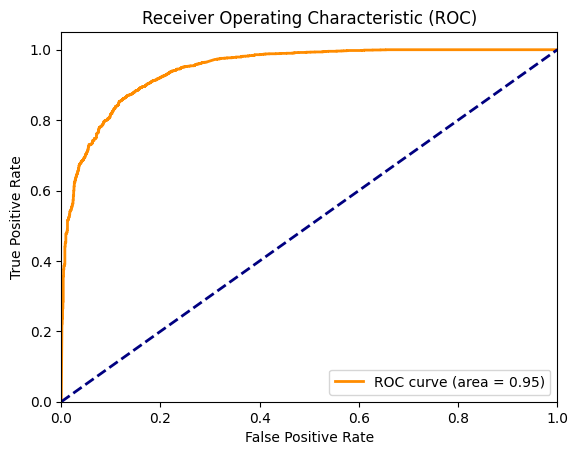

In [8]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for DNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the DNN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('dnn_model_main_best.weights.h5')
print("Model weights saved to 'model_weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

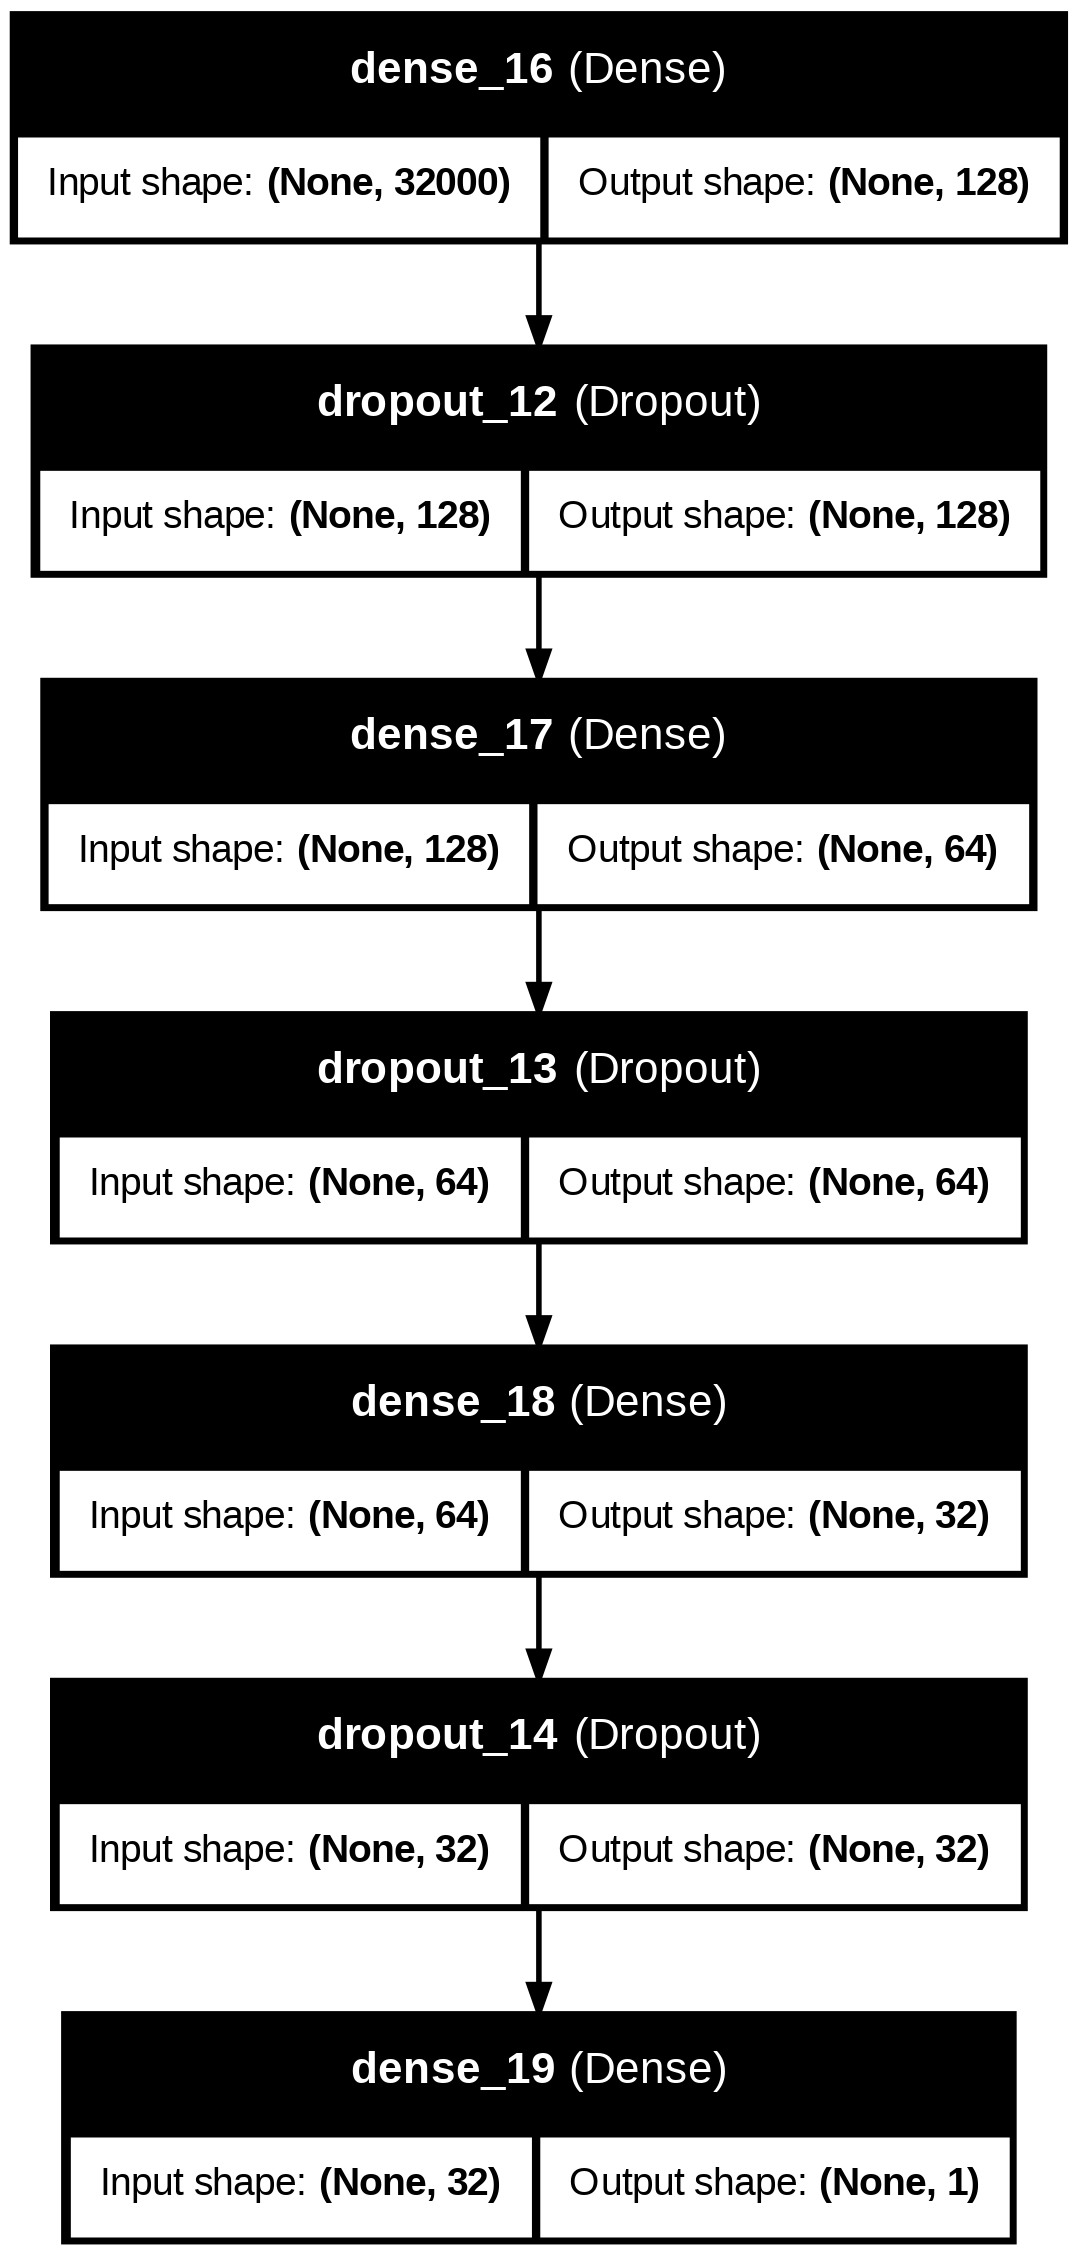

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import plot_model

# Recreate model architecture (must match original)
# Build the DNN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification
])
model.load_weights('/kaggle/working/dnn_model_main_best.weights.h5')  # Path to your weights

# Generate and save summary plot
plot_model(model, to_file='/kaggle/working/model_summary.png', show_shapes=True, show_layer_names=True)

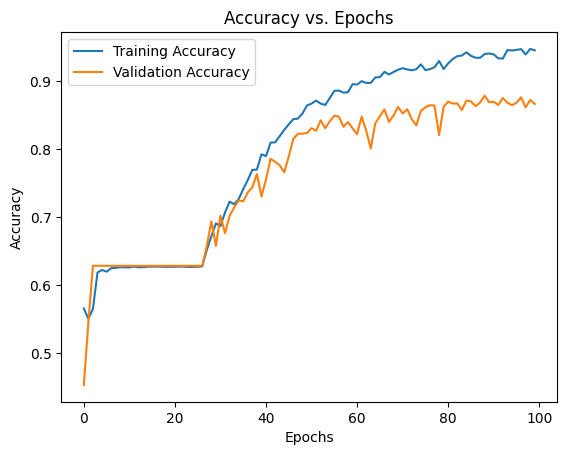

In [14]:
# Compile the model
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# # If history not saved, retrain to get it (or pickle history next time)
# history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Plot accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epochs')
plt.legend()
plt.savefig('/kaggle/working/accuracy_vs_epochs.png')
plt.show()

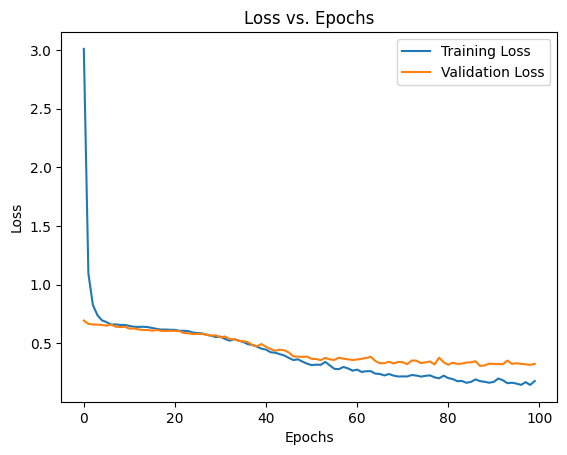

In [15]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs')
plt.legend()
plt.savefig('/kaggle/working/loss_vs_epochs.png')
plt.show()

# **TCN**

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.6153 - loss: 0.8256 - val_accuracy: 0.6271 - val_loss: 0.6138
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6372 - loss: 0.6135 - val_accuracy: 0.7672 - val_loss: 0.5432
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6842 - loss: 0.5491 - val_accuracy: 0.8285 - val_loss: 0.4281
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7465 - loss: 0.4855 - val_accuracy: 0.8442 - val_loss: 0.4003
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8077 - loss: 0.4184 - val_accuracy: 0.8664 - val_loss: 0.3248
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8418 - loss: 0.3607 - val_accuracy: 0.8963 - val_loss: 0.2986
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8627 - loss: 0.3249 - val_accuracy: 0.9073 - val_loss: 0.2250
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8713 - loss: 0.3137 - val_ac

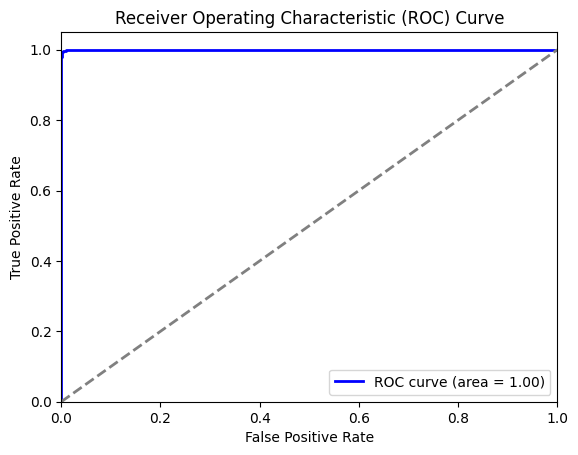

In [16]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Function to create a TCN block
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Assume X is already in 3D shape (samples, timesteps, channels), e.g., (samples, 250, 128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (normalize across channels)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Create a TCN model
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = TCN_block(inputs, filters=64, kernel_size=2, dilation_rate=1)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=2)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=4)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('tcn_model.weights.h5')
print("Model weights saved to 'tcn_model.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.6042 - loss: 0.8381 - val_accuracy: 0.6283 - val_loss: 0.6367
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6325 - loss: 0.6293 - val_accuracy: 0.6289 - val_loss: 0.5938
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6389 - loss: 0.5902 - val_accuracy: 0.7713 - val_loss: 0.5274
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7135 - loss: 0.5345 - val_accuracy: 0.8178 - val_loss: 0.4267
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7953 - loss: 0.4334 - val_accuracy: 0.8762 - val_loss: 0.3464
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8196 - loss: 0.3952 - val_accuracy: 0.9114 - val_loss: 0.3017
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8419 - loss: 0.3464 - val_accuracy: 0.9354 - val_loss: 0.2214
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8577 - loss: 0.3156 - val_accuracy: 

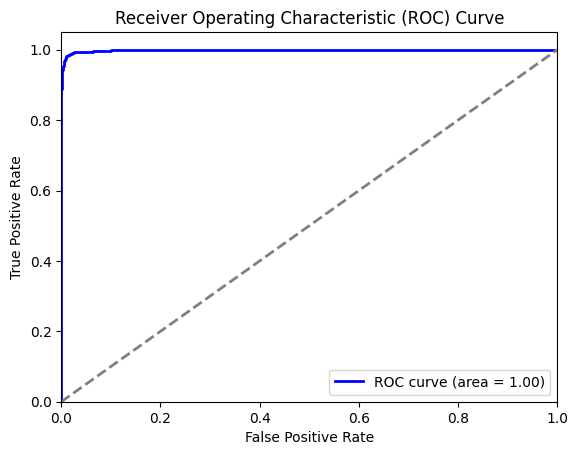

In [18]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Function to create a TCN block
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Assume X is already in 3D shape (samples, timesteps, channels), e.g., (samples, 250, 128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (normalize across channels)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Create a TCN model
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = TCN_block(inputs, filters=64, kernel_size=2, dilation_rate=1)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=2)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=4)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('tcn_model_main.weights.h5')
print("Model weights saved to 'tcn_model_main.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **GAN**

I0000 00:00:1768498720.743084   34070 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1768498722.221416   34105 service.cc:148] XLA service 0x7c0bac005750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768498722.222184   34105 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1768498722.304713   34105 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1768498722.629735   34105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


0 [D loss: 0.8264183402061462, acc.: 51.953125%] [G loss: 0.720899224281311]
100 [D loss: 5.510973930358887, acc.: 19.858993589878082%] [G loss: 0.009353220462799072]
200 [D loss: 6.183188438415527, acc.: 19.582845270633698%] [G loss: 0.004712466150522232]
300 [D loss: 6.622011184692383, acc.: 19.443592429161072%] [G loss: 0.0031507888343185186]
400 [D loss: 6.946325778961182, acc.: 19.33484971523285%] [G loss: 0.0023666853085160255]
500 [D loss: 7.217304229736328, acc.: 19.423994421958923%] [G loss: 0.0018950365483760834]
600 [D loss: 7.442119598388672, acc.: 19.42754089832306%] [G loss: 0.0015802367124706507]
700 [D loss: 7.640130043029785, acc.: 19.40554976463318%] [G loss: 0.0013551143929362297]
800 [D loss: 7.808402061462402, acc.: 19.446614384651184%] [G loss: 0.0011861507082358003]
900 [D loss: 7.960568428039551, acc.: 19.45427656173706%] [G loss: 0.0010546398116275668]
GAN model weights saved to 'gan_model.weights.h5'
Generator and Discriminator weights saved
660/660 ━━━━━━━━━━

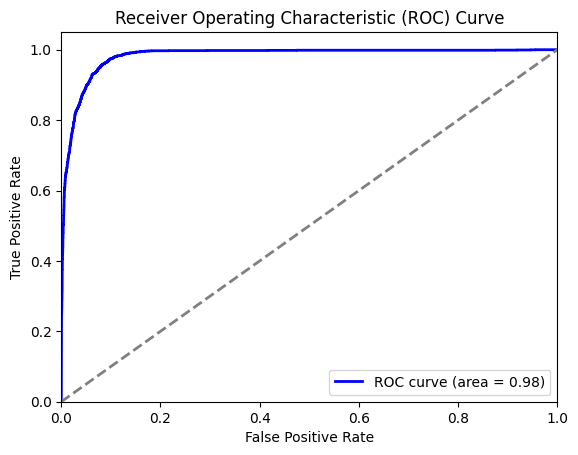

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LeakyReLU, Dropout, Input
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for GAN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Standardize the features
scaler = StandardScaler()
X_flattened = scaler.fit_transform(X_flattened)

# Define GAN components
latent_dim = 100  # Dimension of the latent space (noise input)

# Generator
def build_generator():
    model = Sequential()
    model.add(Dense(256, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(1024))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(X_flattened.shape[1], activation='tanh'))
    return model

# Discriminator
def build_discriminator():
    model = Sequential()
    model.add(Dense(512, input_shape=(X_flattened.shape[1],)))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.4))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Build and compile the discriminator
discriminator = build_discriminator()
discriminator.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5), loss='binary_crossentropy', metrics=['accuracy'])

# Build the generator
generator = build_generator()

# Create GAN by combining generator and discriminator
z = Input(shape=(latent_dim,))
generated_data = generator(z)
discriminator.trainable = False  # Freeze the discriminator during GAN training
validity = discriminator(generated_data)
gan = Model(z, validity)
gan.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5), loss='binary_crossentropy')

# Training parameters
epochs = 1000
batch_size = 64
sample_interval = 100

# Labels for real and fake data
real = np.ones((batch_size, 1))
fake = np.zeros((batch_size, 1))

# Training the GAN
for epoch in range(epochs):
    
    # Train Discriminator
    idx = np.random.randint(0, X_flattened.shape[0], batch_size)
    real_data = X_flattened[idx]
    
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    generated_data_batch = generator.predict(noise, verbose=0)
    
    d_loss_real = discriminator.train_on_batch(real_data, real)
    d_loss_fake = discriminator.train_on_batch(generated_data_batch, fake)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    
    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, real)
    
    # Print progress
    if epoch % sample_interval == 0:
        print(f"{epoch} [D loss: {d_loss[0]}, acc.: {100*d_loss[1]}%] [G loss: {g_loss}]")

# Save GAN weights
gan.save_weights('gan_model.weights.h5')
print("GAN model weights saved to 'gan_model.weights.h5'")

# Save Generator and Discriminator separately
generator.save_weights('generator.weights.h5')
discriminator.save_weights('discriminator.weights.h5')
print("Generator and Discriminator weights saved")

# Generate synthetic data using the trained generator
noise = np.random.normal(0, 1, (X_flattened.shape[0], latent_dim))
synthetic_data = generator.predict(noise)

# Assign labels to synthetic data (same shape as X_flattened)
synthetic_labels = np.zeros(X_flattened.shape[0])

# Combine real and synthetic data
combined_X = np.vstack((X_flattened, synthetic_data))
combined_y = np.hstack((y, synthetic_labels))

# Split combined data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(combined_X, combined_y, test_size=0.2, random_state=42)

# Train the discriminator as a binary classifier
discriminator.trainable = True  # Unfreeze the discriminator for fine-tuning
discriminator.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5), loss='binary_crossentropy', metrics=['accuracy'])
discriminator.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, verbose=1)

# Make predictions
y_pred_prob = discriminator.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **FFNN**

2026-01-16 07:31:20.462788: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768548680.679788      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768548680.733828      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768548681.194769      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768548681.194818      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768548681.194821      55 computation_placer.cc:177] computation placer alr

Epoch 1/100


I0000 00:00:1768548727.441417     124 service.cc:152] XLA service 0x7ed2ac00ad20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768548727.441455     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1768548727.819138     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


 40/422 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5533 - loss: 3.9378

I0000 00:00:1768548729.867920     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

 Total params: 12,319,493 (47.00 MB)

 Trainable params: 4,106,497 (15.67 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,212,996 (31.33 MB)

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy: 0.8644228490163546
Confusion Matrix:
[[1306  216]
 [ 356 2341]]
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82      1522
           1       0.92      0.87      0.89      2697

    accuracy                           0.86      4219
   macro avg       0.85      0.86      0.86      4219
weighted avg       0.87      0.86      0.87      4219



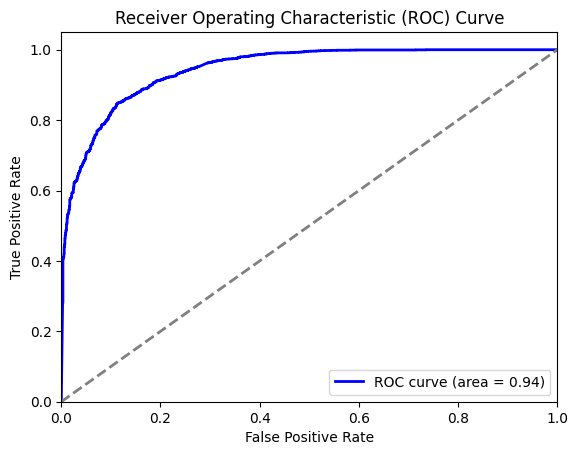

In [2]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for FFNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a Feedforward Neural Network (FFNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    
    Dense(64, activation='relu'),
    Dropout(0.5),
    
    Dense(32, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('ffnn_model.weights.h5')
print("Model weights saved to 'ffnn_model.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5577 - loss: 4.9186 - val_accuracy: 0.5065 - val_loss: 0.6912
Epoch 2/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5361 - loss: 1.3100 - val_accuracy: 0.5347 - val_loss: 0.6790
Epoch 3/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5844 - loss: 0.7481 - val_accuracy: 0.6283 - val_loss: 0.6648
Epoch 4/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6322 - loss: 0.6864 - val_accuracy: 0.6283 - val_loss: 0.6621
Epoch 5/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6259 - loss: 0.6940 - val_accuracy: 0.6283 - val_loss: 0.6601
Epoch 6/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6236 - loss: 0.6676 - val_accuracy: 0.6283 - val_loss: 0.6455
Epoch 7/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6224 - loss: 0.6716 - val_accuracy: 0.6283 - val_loss: 0.6404
Epoch 8/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6284 - loss: 0.6764 - val_acc

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │     4,096,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,319,493 (47.00 MB)

 Trainable params: 4,106,497 (15.67 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,212,996 (31.33 MB)

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy: 0.8705854467883385
Confusion Matrix:
[[1340  182]
 [ 364 2333]]
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83      1522
           1       0.93      0.87      0.90      2697

    accuracy                           0.87      4219
   macro avg       0.86      0.87      0.86      4219
weighted avg       0.88      0.87      0.87      4219



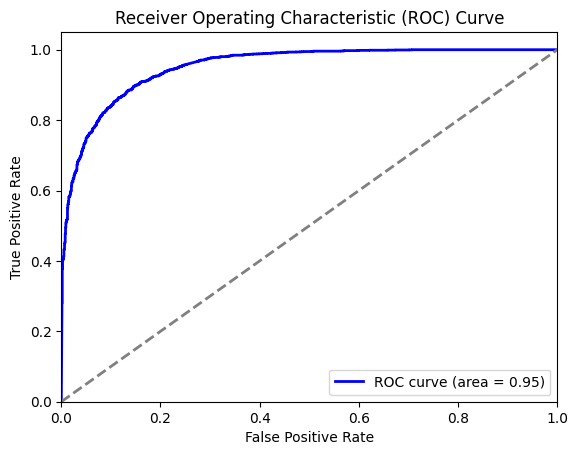

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for FFNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a Feedforward Neural Network (FFNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    
    Dense(64, activation='relu'),
    Dropout(0.5),
    
    Dense(32, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=150, batch_size=16, validation_split=0.2)

# Save model's weights
model.save_weights('ffnn_model_main.weights.h5')
print("Model weights saved to 'ffnn_model.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **BNN WITH DVI**

2026-01-16 09:22:33.897066: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768555354.080736      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768555354.141897      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768555354.575475      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768555354.575526      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768555354.575529      55 computation_placer.cc:177] computation placer alr

Epoch 1/100


I0000 00:00:1768555398.140383     128 service.cc:152] XLA service 0x7efa600078d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768555398.140442     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1768555398.445792     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


 40/422 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5426 - loss: 3.6605

I0000 00:00:1768555399.900633     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5674 - loss: 3.8902 - val_accuracy: 0.6268 - val_loss: 0.8366
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5997 - loss: 1.5524 - val_accuracy: 0.5820 - val_loss: 0.6132
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5936 - loss: 0.9115 - val_accuracy: 0.5767 - val_loss: 0.6193
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6112 - loss: 0.6798 - val_accuracy: 0.6220 - val_loss: 0.6109
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6247 - loss: 0.6452 - val_accuracy: 0.6306 - val_loss: 0.6062
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6329 - loss: 0.6369 - val_accuracy: 0.6570 - val_loss: 0.6017
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6423 - loss: 0.6044 - val_accuracy: 0.6638 - val_loss: 0.5859
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6546 - loss: 0.5963 - val_accuracy: 0.673

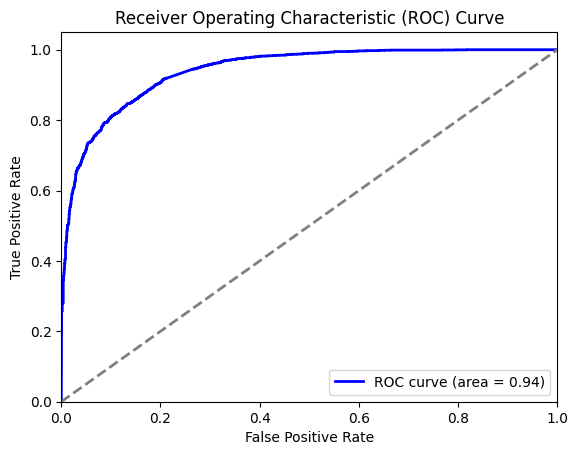

In [2]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for BNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a BNN model with Dropout Variational Inference
def create_bnn_model(input_shape):
    model = Sequential([
        Dense(128, activation='relu', input_shape=input_shape),
        Dropout(0.5),  # Dropout layer to approximate Bayesian posterior
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Define input shape based on flattened data
input_shape = (X_train.shape[1],)

# Create the BNN model
model = create_bnn_model(input_shape)

# Train the model (without early stopping)
history = model.fit(
    X_train, 
    y_train, 
    epochs=100, 
    batch_size=32, 
    validation_split=0.2
)

# Save model's weights
model.save_weights('bnn_model.weights.h5')
print("Model weights saved to 'bnn_model.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5756 - loss: 4.0578 - val_accuracy: 0.6401 - val_loss: 0.8107
Epoch 2/150
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6007 - loss: 1.5792 - val_accuracy: 0.6185 - val_loss: 0.6039
Epoch 3/150
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5937 - loss: 0.8752 - val_accuracy: 0.6176 - val_loss: 0.6081
Epoch 4/150
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6124 - loss: 0.7065 - val_accuracy: 0.6140 - val_loss: 0.6073
Epoch 5/150
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6191 - loss: 0.6745 - val_accuracy: 0.6404 - val_loss: 0.5978
Epoch 6/150
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6455 - loss: 0.6239 - val_accuracy: 0.6656 - val_loss: 0.5934
Epoch 7/150
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6326 - loss: 0.6299 - val_accuracy: 0.6537 - val_loss: 0.5945
Epoch 8/150
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6462 - loss: 0.6086 - val_acc

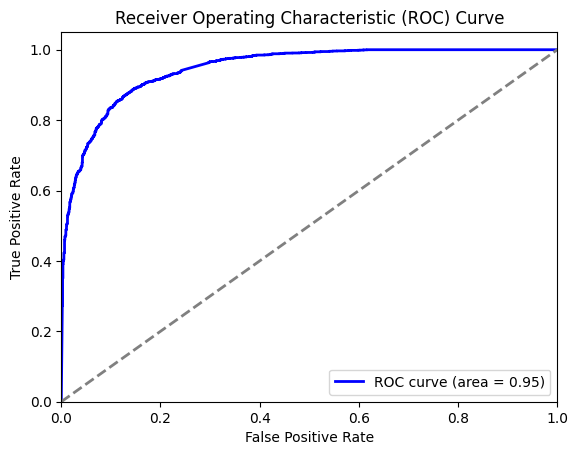

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for BNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a BNN model with Dropout Variational Inference
def create_bnn_model(input_shape):
    model = Sequential([
        Dense(128, activation='relu', input_shape=input_shape),
        Dropout(0.5),  # Dropout layer to approximate Bayesian posterior
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Define input shape based on flattened data
input_shape = (X_train.shape[1],)

# Create the BNN model
model = create_bnn_model(input_shape)

# Train the model (without early stopping)
history = model.fit(
    X_train, 
    y_train, 
    epochs=150, 
    batch_size=32, 
    validation_split=0.2
)

# Save model's weights
model.save_weights('bnn_model_main.weights.h5')
print("Model weights saved to 'bnn_model.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5759 - loss: 3.4758 - val_accuracy: 0.6280 - val_loss: 0.6360
Epoch 2/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5872 - loss: 1.2891 - val_accuracy: 0.5699 - val_loss: 0.6207
Epoch 3/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5949 - loss: 0.7872 - val_accuracy: 0.5566 - val_loss: 0.6240
Epoch 4/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6159 - loss: 0.6904 - val_accuracy: 0.6049 - val_loss: 0.6125
Epoch 5/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6250 - loss: 0.6531 - val_accuracy: 0.6602 - val_loss: 0.6039
Epoch 6/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6362 - loss: 0.6378 - val_accuracy: 0.6659 - val_loss: 0.5946
Epoch 7/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6473 - loss: 0.6151 - val_accuracy: 0.6694 - val_loss: 0.5859
Epoch 8/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6543 - loss: 0.5970 - val_acc

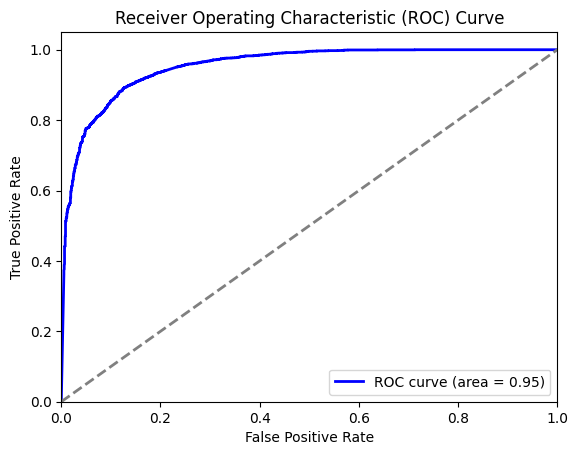

In [5]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for BNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a BNN model with Dropout Variational Inference
def create_bnn_model(input_shape):
    model = Sequential([
        Dense(128, activation='relu', input_shape=input_shape),
        Dropout(0.5),  # Dropout layer to approximate Bayesian posterior
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Define input shape based on flattened data
input_shape = (X_train.shape[1],)

# Create the BNN model
model = create_bnn_model(input_shape)

# Train the model (without early stopping)
history = model.fit(
    X_train, 
    y_train, 
    epochs=250, 
    batch_size=32, 
    validation_split=0.2
)

# Save model's weights
model.save_weights('bnn_model_main_best_2.weights.h5')
print("Model weights saved to 'bnn_model.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **CNN**

In [6]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, MaxPooling2D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Reshape data to fit the CNN model (e.g., add channels dimension: samples, time, channels, 1)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)  # Reshaping to (samples, time, channels, 1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[3])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[3])).reshape(X_test.shape)

# Create a CNN model
model = Sequential([
    Conv2D(32, (1, 1), activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2], 1)),  # Adjusted kernel size
    MaxPooling2D(pool_size=(1, 1)),
    Dropout(0.25),
    
    Conv2D(64, (1, 1), activation='tanh'),
    MaxPooling2D(pool_size=(1, 1)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='tanh'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('cnn_model.weights.h5')
print("Model weights saved to 'cnn_model.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 57s 109ms/step - accuracy: 0.5414 - loss: 1.1569 - val_accuracy: 0.6241 - val_loss: 0.6559
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.5866 - loss: 0.6999 - val_accuracy: 0.6253 - val_loss: 0.6564
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.6064 - loss: 0.6659 - val_accuracy: 0.6259 - val_loss: 0.6491
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.6110 - loss: 0.6554 - val_accuracy: 0.6277 - val_loss: 0.6491
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.6097 - loss: 0.6583 - val_accuracy: 0.6268 - val_loss: 0.6461
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.6173 - loss: 0.6562 - val_accuracy: 0.6280 - val_loss: 0.6438
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.6063 - loss: 0.6615 - val_accuracy: 0.6280 - val_loss: 0.6481
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.6228 - loss: 

KeyboardInterrupt: 

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.7196 - loss: 0.6099 - val_accuracy: 0.9191 - val_loss: 0.2134
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9260 - loss: 0.1844 - val_accuracy: 0.9532 - val_loss: 0.1287
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9670 - loss: 0.0875 - val_accuracy: 0.9733 - val_loss: 0.0810
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9816 - loss: 0.0501 - val_accuracy: 0.9775 - val_loss: 0.0665
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9912 - loss: 0.0282 - val_accuracy: 0.9828 - val_loss: 0.0559
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9893 - loss: 0.0303 - val_accuracy: 0.9822 - val_loss: 0.0506
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9936 - loss: 0.0168 - val_accuracy: 0.9781 - val_loss: 0.0663
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9958 - loss: 0.0123 - val_acc

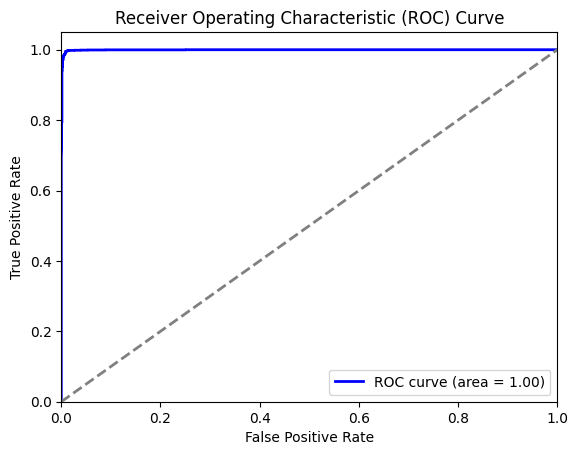

In [10]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, MaxPooling2D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Reshape data to fit the CNN model (e.g., add channels dimension: samples, time, channels, 1)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)  # Reshaping to (samples, time, channels, 1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[3])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[3])).reshape(X_test.shape)

# Create a CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1)),  # Adjusted kernel size
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='tanh'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('cnn_model.weights.h5')
print("Model weights saved to 'cnn_model.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **MLPNN**

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for MLPNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a Multilayer Perceptron (MLP) model
model = Sequential([
    Dense(128, activation='tanh', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    
    Dense(64, activation='tanh'),
    Dropout(0.5),
    
    Dense(32, activation='tanh'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('mlpnn_model.weights.h5')
print("Model weights saved to 'mlpnn_model.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()